# Tests Statistiques : Blum-Blum-Shub (BBS)
Évaluation des propriétés d'uniformité du générateur cryptographique BBS.

In [13]:
import sys
import os
import math
import numpy as np
from scipy import stats
from collections import Counter

sys.path.append(os.path.abspath('..'))
from generators.bbs import BlumBlumShub

def shannon_entropy(data):
    probs = [count / len(data) for count in Counter(data).values()]
    return -sum(p * math.log2(p) for p in probs)

def chi_square_uniformity(data):
    expected = len(data) / 256.0
    freqs = [data.count(i) for i in range(256)]
    return stats.chisquare(freqs, f_exp=[expected]*256)

def autocorrelation(data, lag=1):
    x = np.array(data)
    return np.corrcoef(x[:-lag], x[lag:])[0, 1]

def ks_test_uniformity(data):
    normalized = [b / 255.0 for b in data]
    return stats.kstest(normalized, 'uniform')

In [14]:

p, q = 30000000091, 40000000003 
bbs = BlumBlumShub(p, q, seed=123456789)

data_bbs = []
for _ in range(50000):
    byte_val = 0
    for i in range(8):
        byte_val = (byte_val << 1) | bbs.next_bit()
    data_bbs.append(byte_val)

# Résultats
print(f"Entropie : {shannon_entropy(data_bbs):.4f} (Idéal: ~8.0)")
print(f"Chi-2    : p-value = {chi_square_uniformity(data_bbs)[1]:.4f}")
print(f"AutoCorr (lag 1) : {autocorrelation(data_bbs, lag=1):.4f} (Idéal: ~0)")
print(f"AutoCorr (lag 8) : {autocorrelation(data_bbs, lag=8):.4f} (Idéal: ~0)")
print(f"Test KS  : p-value = {ks_test_uniformity(data_bbs)[1]:.4f}")

Entropie : 7.9961 (Idéal: ~8.0)
Chi-2    : p-value = 0.2902
AutoCorr (lag 1) : -0.0046 (Idéal: ~0)
AutoCorr (lag 8) : 0.0014 (Idéal: ~0)
Test KS  : p-value = 0.1548


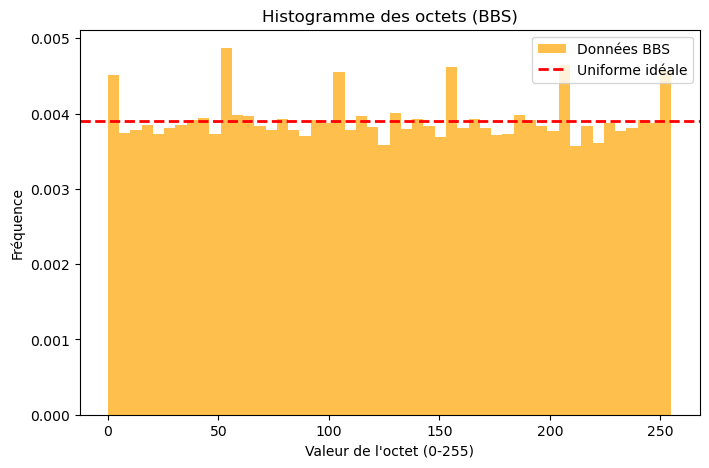

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Histogramme d'uniformité pour BBS
plt.hist(data_bbs, bins=50, density=True, alpha=0.7, color='orange', label="Données BBS")
plt.axhline(y=1/256, color='red', linestyle='dashed', linewidth=2, label="Uniforme idéale")

plt.title("Histogramme des octets (BBS)")
plt.xlabel("Valeur de l'octet (0-255)")
plt.ylabel("Fréquence")
plt.legend()

plt.show()

Le générateur Blum-Blum-Shub (BBS) offre une sécurité théorique très forte, reposant sur la difficulté de la factorisation des grands nombres. Ses excellents résultats statistiques le confirment. Cependant, il est extrêmement lent en pratique : il nécessite une exponentiation modulaire coûteuse pour n'extraire qu'un seul bit de parité à la fois. Il est donc très sûr, mais inadapté pour générer de gros volumes de données rapidement.